In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from uvv.uvv_collection import UVVCollection
from itertools import product
import os

In [ ]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))


Materials: ['BLPHI4', 'LN28_1', 'LN28_2', 'LN31_1', 'LN28SBA_1', 'LN46', 'LN33', 'BLPHI', 'LN31_2', 'LN28', 'LN31', 'LN55']
Wavelengths: [450, 365, 406]
Loadings: ['1-0', '0-75', '1-5', '0-25', '0-5', '73-5h', '2-0']
Sonications: [0, 10]
Phases: ['aqueous']
Dates: ['0124', 202401, '202402xx', '202311xx', '20230430', '20231204', '2023-02-xx', 20240209, 20231121, 20231123, '202307xx', '202401xx', '20240209', '20230804']
{'BLPHI_365nm_1-5_g_L_0min_aqueous_202311xx.csv', 'LN31_1_365nm_73-5h_g_L_10min_aqueous_20231123.csv', 'BLPHI4_450nm_2-0_g_L_10min_aqueous_2023-02-xx.csv', 'LN28_2_365nm_1-0_g_L_10min_aqueous_20240209.csv', 'LN46_406nm_1-5_g_L_0min_aqueous_20231123.csv', 'LN31_1_365nm_1-5_g_L_0min_aqueous_20240209.csv', 'LN46_365nm_0-25_g_L_10min_aqueous_20230804.csv', 'BLPHI4_406nm_73-5h_g_L_0min_aqueous_20230804.csv', 'LN55_450nm_73-5h_g_L_10min_aqueous_202311xx.csv', 'LN33_450nm_0-75_g_L_0min_aqueous_20230430.csv', 'LN31_406nm_0-5_g_L_10min_aqueous_202307xx.csv', 'LN28_450nm_0-25_g_L_1

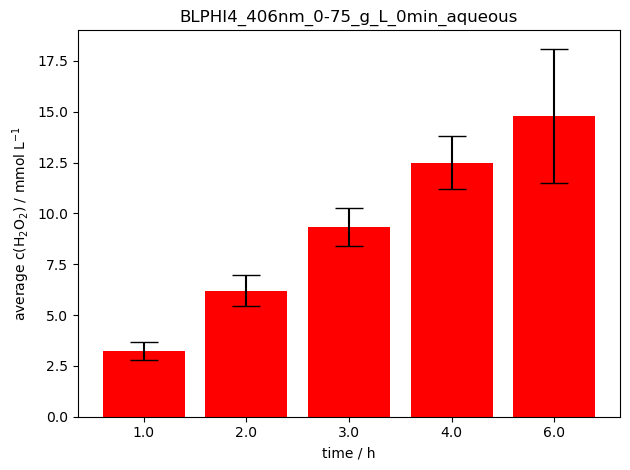

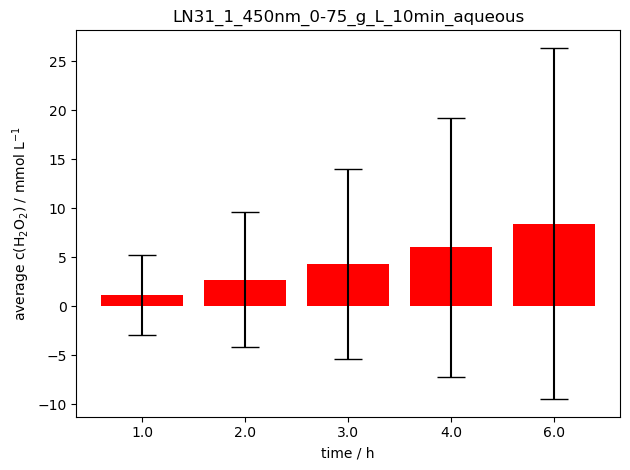

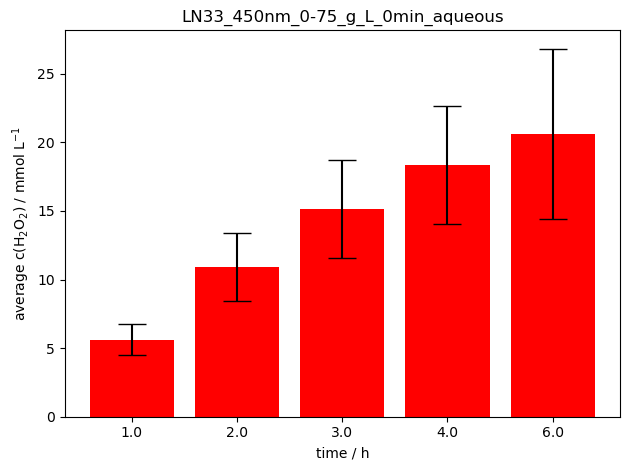

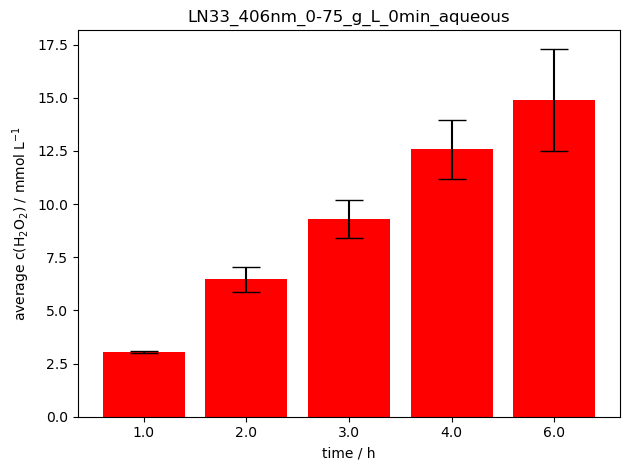

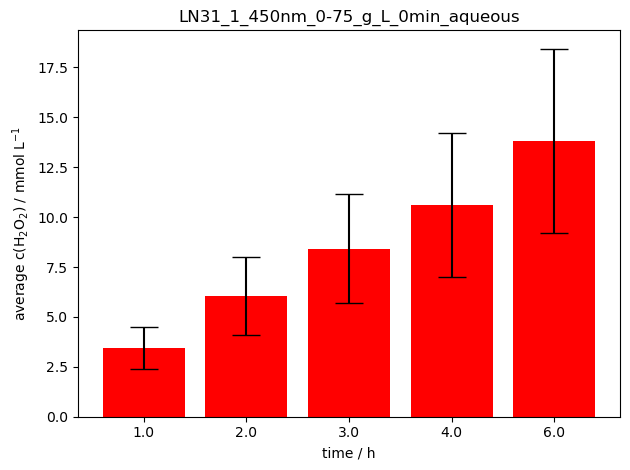

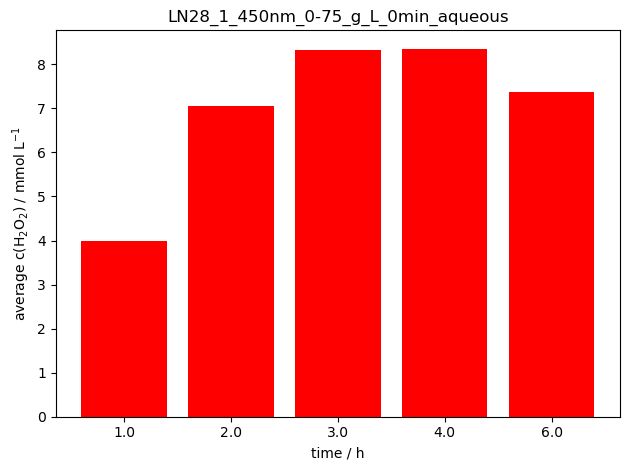

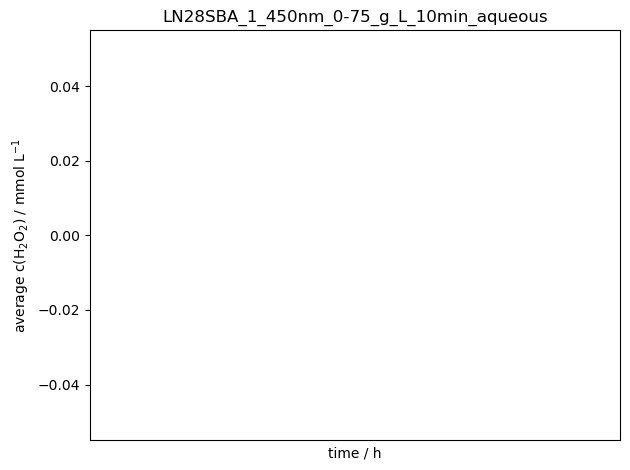

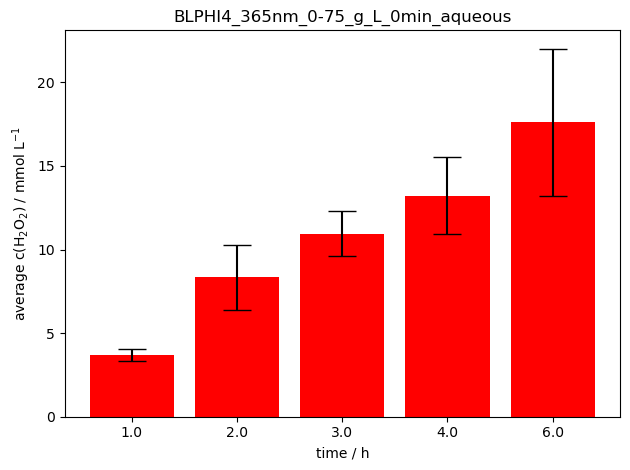

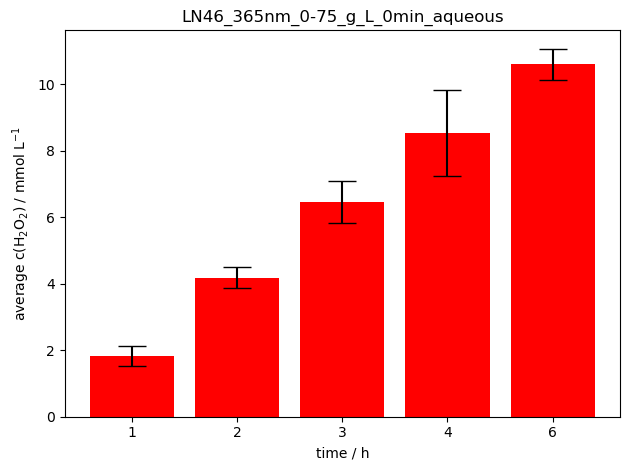

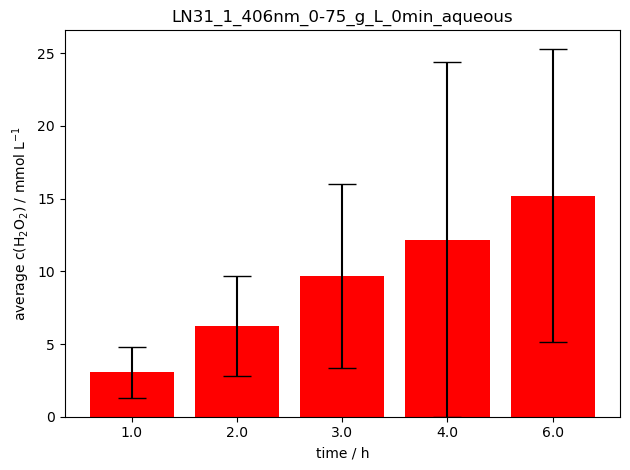

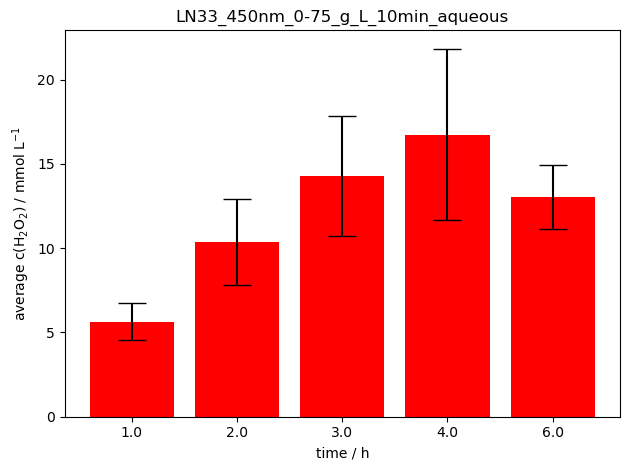

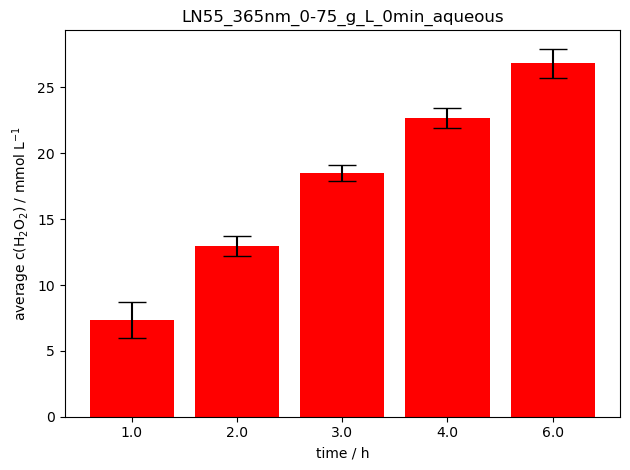

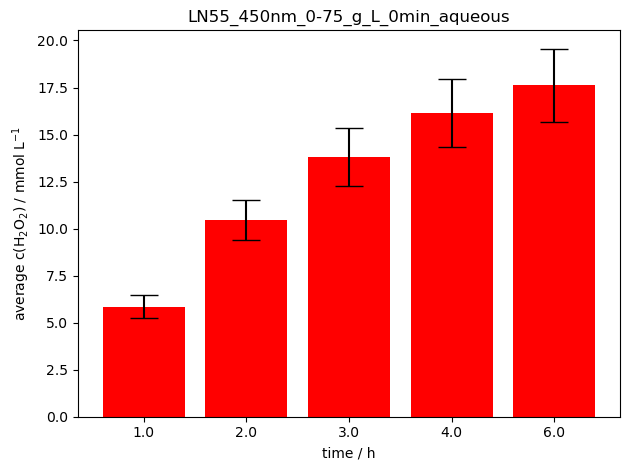

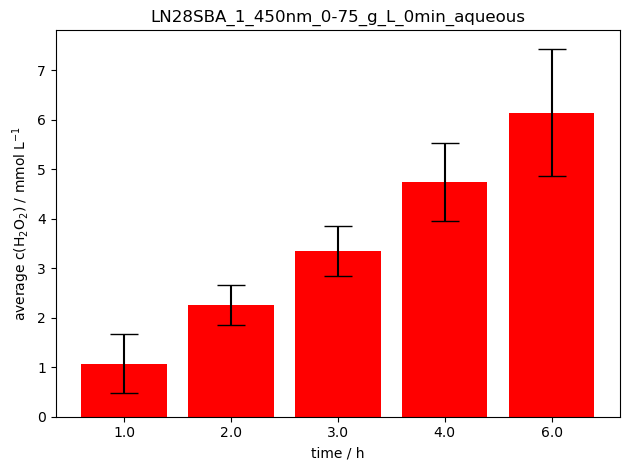

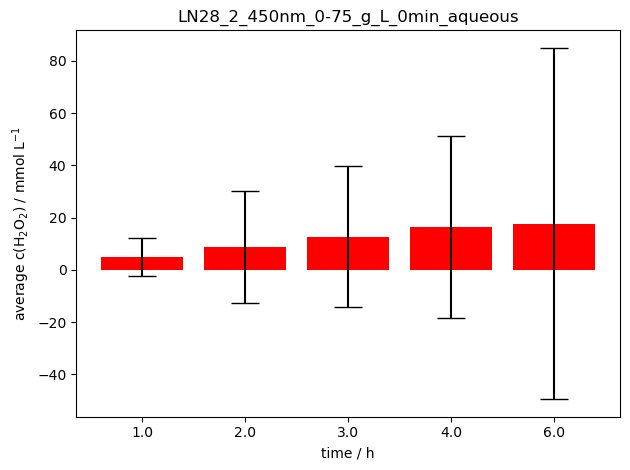

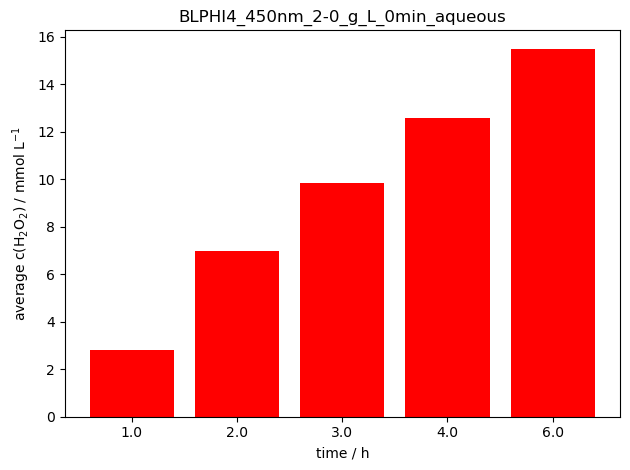

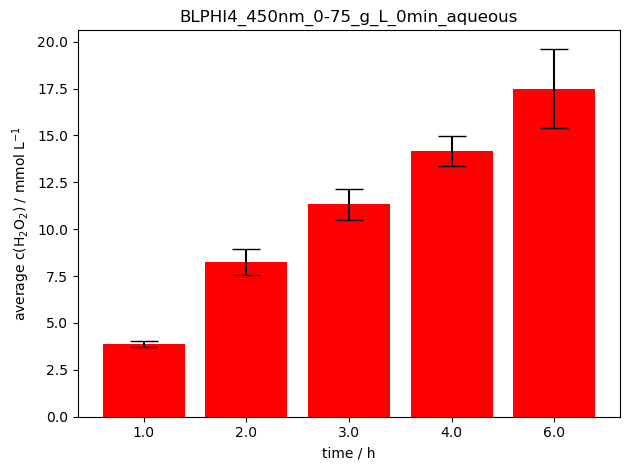

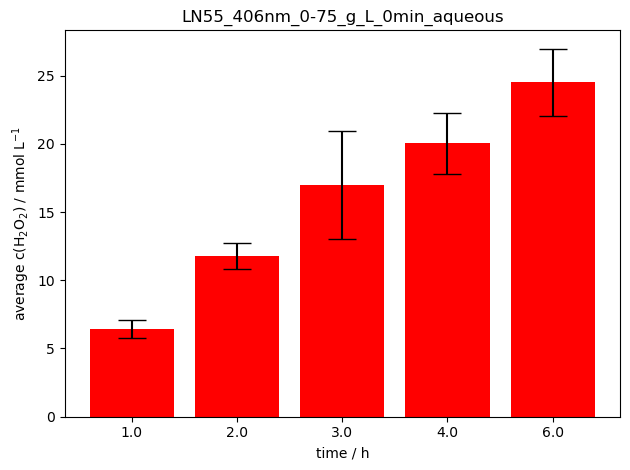

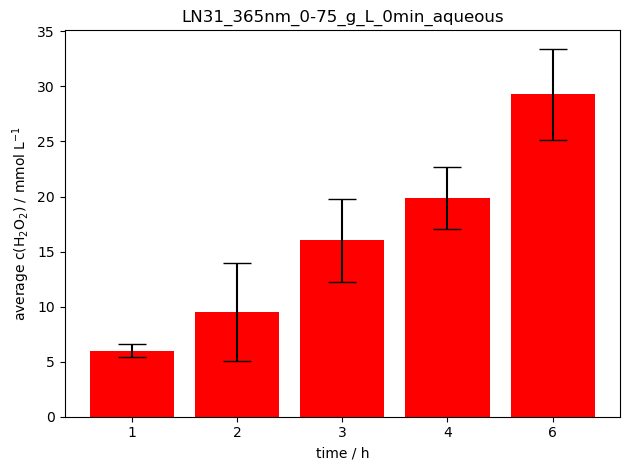

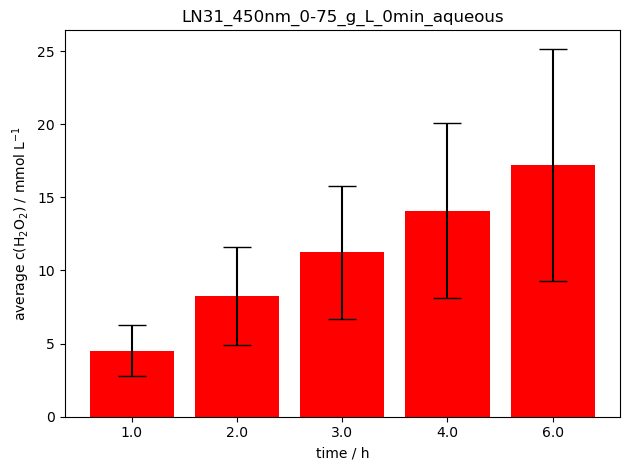

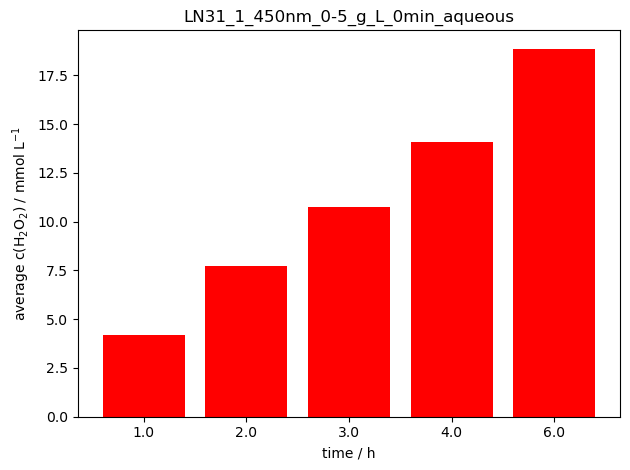

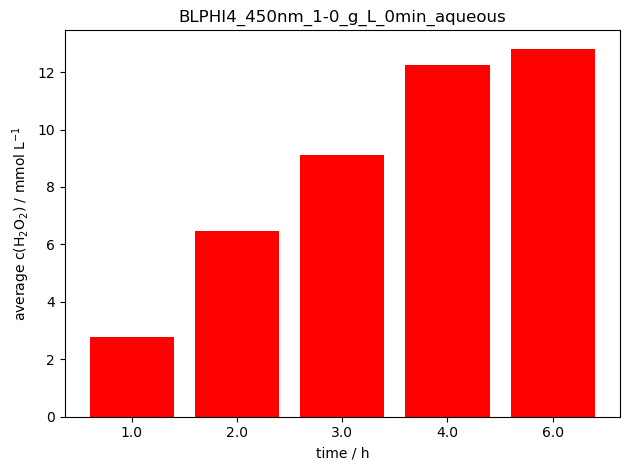

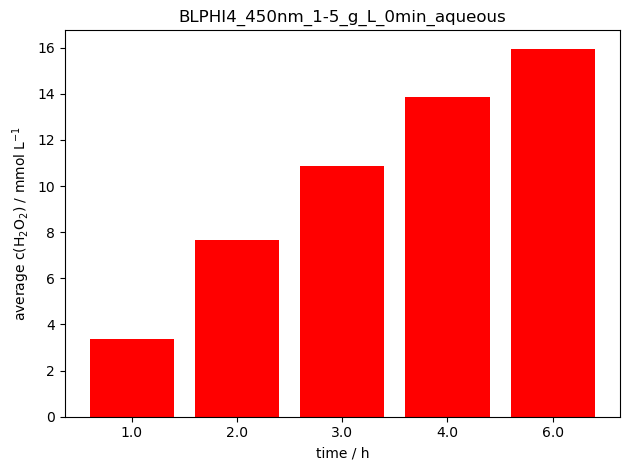

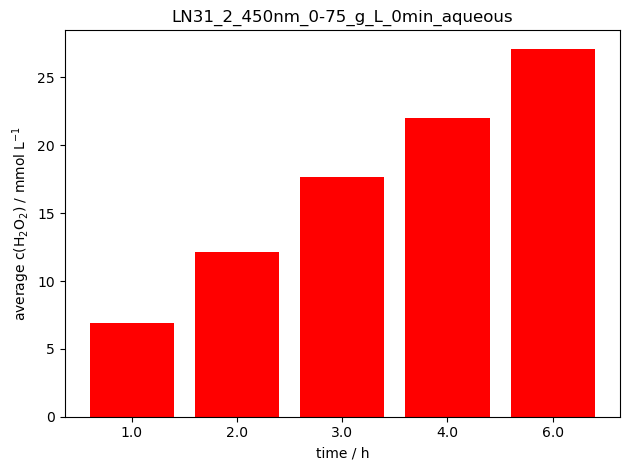

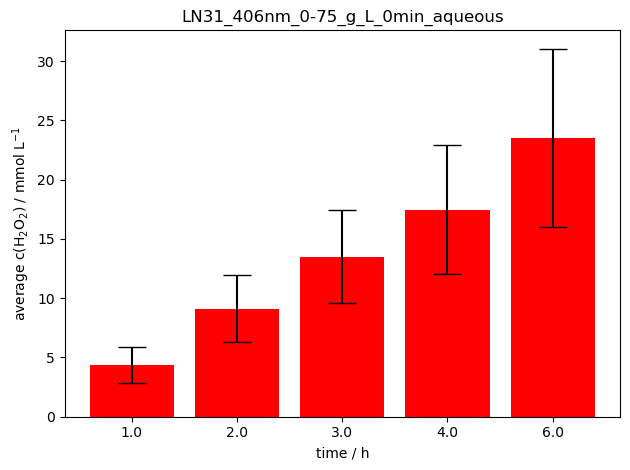

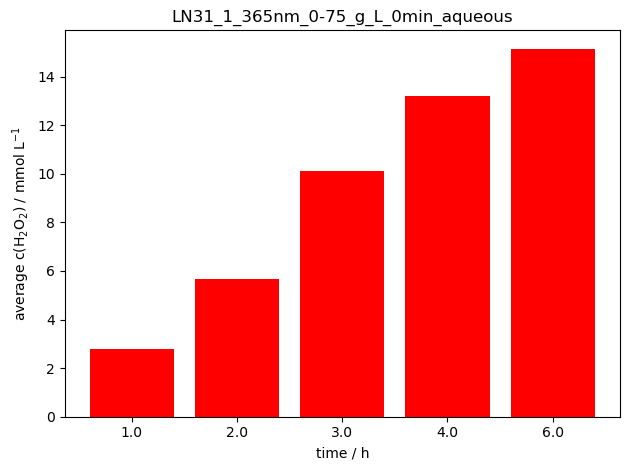

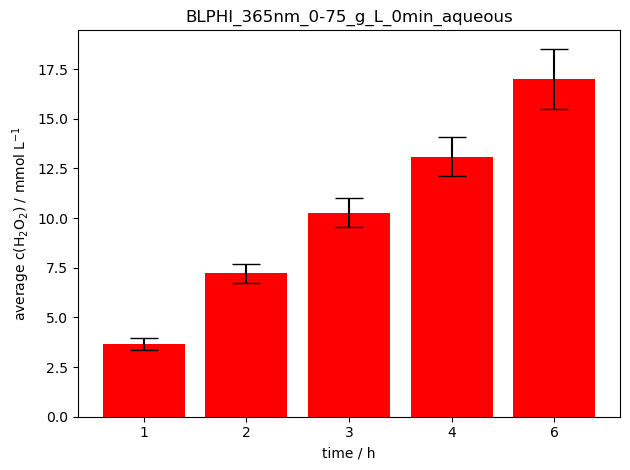

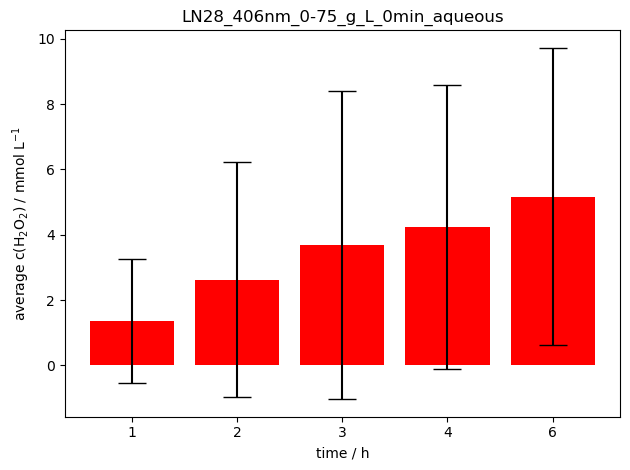

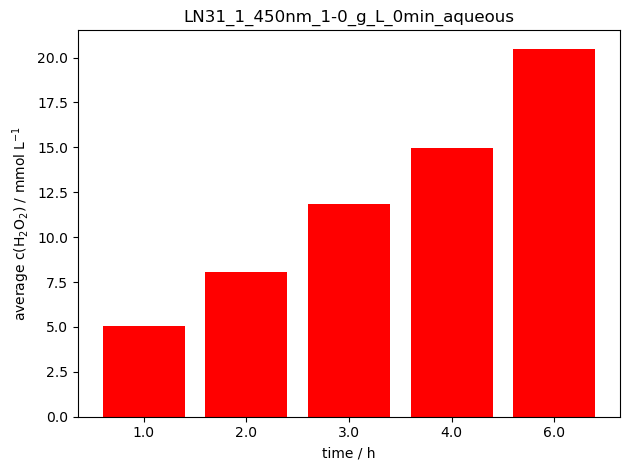

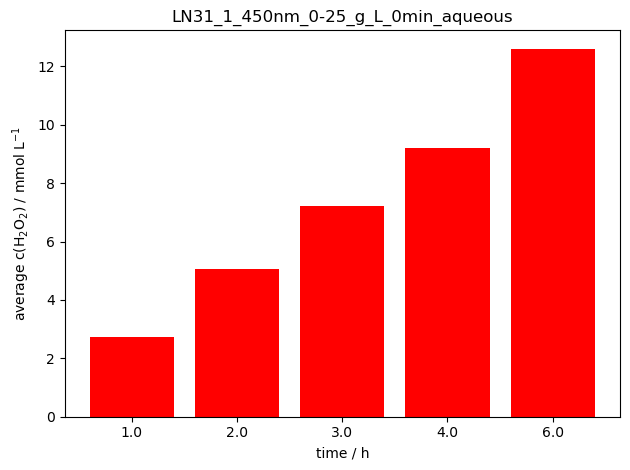

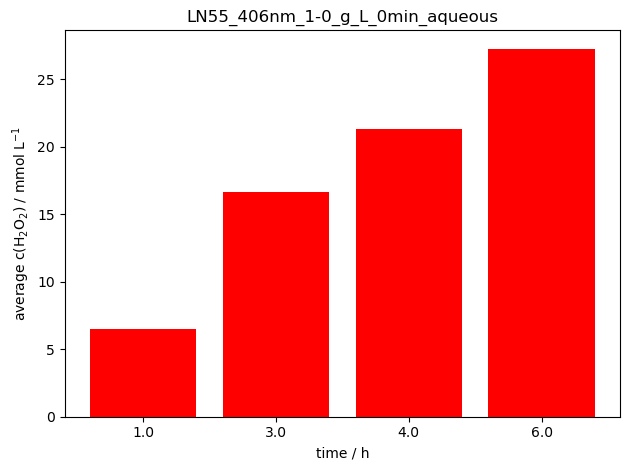

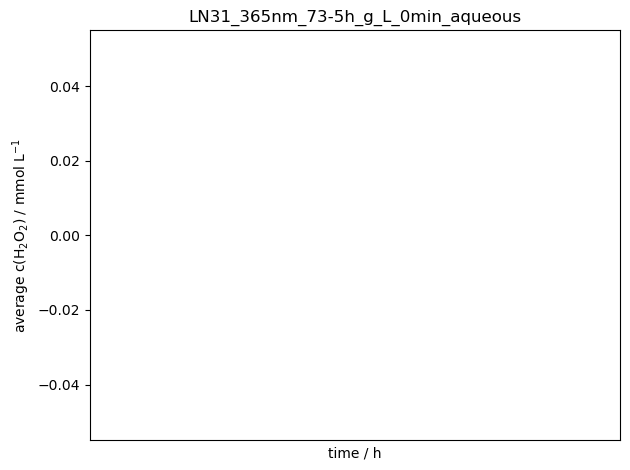

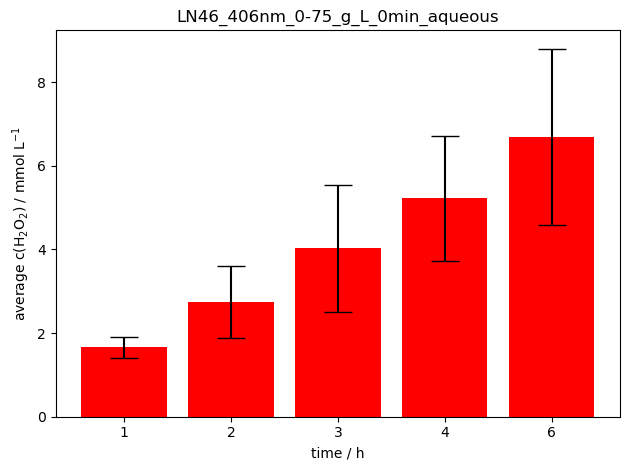

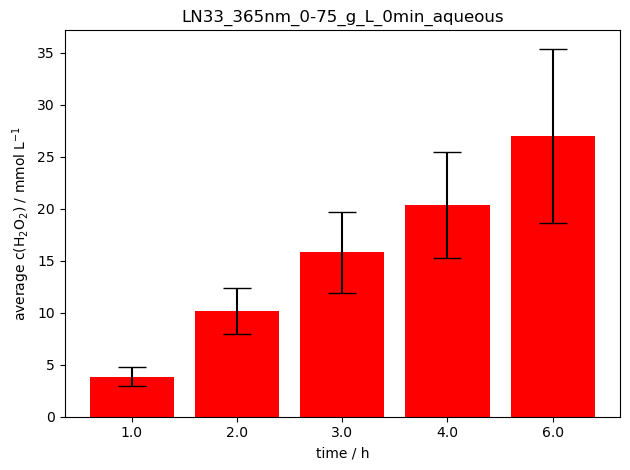

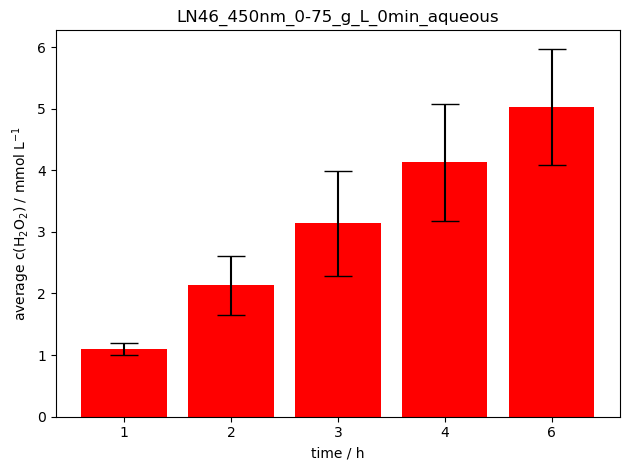

In [12]:
package_dir = 'data/raw_mrdga/neuer_trial/exp'
uvcoll = UVVCollection.from_local(package_dir).remove_repeated()
uvcoll.make_nice_bar_plots()
uvcoll.make_nice_bar_plots_ignore_synthesis_date()

## Making nice bar plots (save them to the evaluation folder) - seperating data by the synhtesis date of the material

In [ ]:
def make_nice_bar_plots(uvcoll):
        from itertools import product
        import matplotlib.pyplot as plt

        def extract_filter_criteria(uvcoll):
            materials = list(set([entry.system.material.name for entry in uvcoll]))
            wavelengths = list(set([entry.system.wavelength.value for entry in uvcoll]))
            loadings = list(set([str(entry.system.Loading.value).replace('.', '-') for entry in uvcoll]))
            sonications = list(set([entry.system.sonication.time.value for entry in uvcoll]))
            sonications = [0 if sonication is None else sonication for sonication in sonications]
            phases = list(set([entry.extraction[0].sample_extracted.phase for entry in uvcoll]))
            date = list(set([entry.system.material.synthesis_date for entry in uvcoll]))
            return materials, wavelengths, loadings, sonications, phases, date

        materials, wavelengths, loadings, sonications, phases, date = extract_filter_criteria(uvcoll)
        print("Materials:", materials)
        print("Wavelengths:", wavelengths)
        print("Loadings:", loadings)
        print("Sonications:", sonications)
        print("Phases:", phases)
        print("Dates:", date)

        # Generate all possible combinations of materials, wavelengths, and loadings
        combinations = list(product(materials, wavelengths, loadings, sonications, phases, date))

        # Create a set of unique filenames
        filenames_set = {
            f"{material}_{wavelength}nm_{loading}_g_L_{sonication}min_{phase}_{date}.csv"
            for material, wavelength, loading, sonication, phase, date in combinations
        }
        print(filenames_set)
    
        # Read the CSV files for each combination and exclude files that do not exist
        filenames_dict = {}
        for filename in filenames_set:
            filepath = f'data/old_evaluation/material_excwavelength_loading_sonication/{filename}'
            if os.path.exists(filepath):
                filenames_dict[filename] = filepath
            else:
                print(f"File not found: {filename}")

        print(filenames_dict)
        for filename, filepath in filenames_dict.items():
            df = pd.read_csv(filepath)
            df_filtered = df[df['times'].isin([1, 2, 3, 4, 6])]
            fig, ax = plt.subplots()
            ax.bar([str(time) for time in df_filtered['times']], df_filtered['average_c'], yerr=df_filtered['95% confidence interval'], align='center', alpha=1.0, ecolor='black', capsize=10, color='red')
            ax.set_ylabel('average c(H$_2$O$_2$) / mmol L$^{-1}$')
            ax.set_xticks([str(time) for time in df_filtered['times']])
            ax.set_xticklabels(df_filtered['times'])
            ax.set_xlabel('time / h')
            ax.set_title(f'{filename.replace(".csv", "")}')
            plt.tight_layout()
            plt.savefig(f'data/old_evaluation/material_excwavelength_loading_sonication/{filename.replace(".csv", "")}.png')
            plt.show()
make_nice_bar_plots(uvcoll)

## Making nice bar plots (save them to the evaluation folder) - making no difference by the synhtesis date of the material

In [ ]:
def make_nice_bar_plots_ignore_synthesis_date(uvcoll):
    from itertools import product
    import matplotlib.pyplot as plt

    def extract_filter_criteria(uvcoll):
        materials = list(set([entry.system.material.name for entry in uvcoll]))
        wavelengths = list(set([entry.system.wavelength.value for entry in uvcoll]))
        loadings = list(set([str(entry.system.Loading.value).replace('.', '-') for entry in uvcoll]))
        sonications = list(set([entry.system.sonication.time.value for entry in uvcoll]))
        sonications = [0 if sonication is None else sonication for sonication in sonications]
        phases = list(set([entry.extraction[0].sample_extracted.phase for entry in uvcoll]))
        return materials, wavelengths, loadings, sonications, phases

    materials, wavelengths, loadings, sonications, phases = extract_filter_criteria(uvcoll)
    print("Materials:", materials)
    print("Wavelengths:", wavelengths)
    print("Loadings:", loadings)
    print("Sonications:", sonications)
    print("Phases:", phases)

    # Generate all possible combinations of materials, wavelengths, and loadings
    combinations = list(product(materials, wavelengths, loadings, sonications, phases))

    # Create a set of unique filenames
    filenames_set = {
        f"{material}_{wavelength}nm_{loading}_g_L_{sonication}min_{phase}.csv"
        for material, wavelength, loading, sonication, phase in combinations
    }
    print(filenames_set)

    # Read the CSV files for each combination and exclude files that do not exist
    filenames_dict = {}
    for filename in filenames_set:
        filepath = f'data/old_evaluation/material_excwavelength_loading_sonication/ignore_synthesis_date/{filename}'
        if os.path.exists(filepath):
            filenames_dict[filename] = filepath
        else:
            print(f"File not found: {filename}")

    print(filenames_dict)
    for filename, filepath in filenames_dict.items():
        df = pd.read_csv(filepath)
        df_filtered = df[df['times'].isin([1, 2, 3, 4, 6])]
        fig, ax = plt.subplots()
        ax.bar([str(time) for time in df_filtered['times']], df_filtered['average_c'], yerr=df_filtered['95% confidence interval'], align='center', alpha=1.0, ecolor='black', capsize=10, color='red')
        ax.set_ylabel('average c(H$_2$O$_2$) / mmol L$^{-1}$')
        ax.set_xticks([str(time) for time in df_filtered['times']])
        ax.set_xticklabels(df_filtered['times'])
        ax.set_xlabel('time / h')
        ax.set_title(f'{filename.replace(".csv", "")}')
        plt.tight_layout()
        plt.savefig(f'data/old_evaluation/material_excwavelength_loading_sonication/ignore_synthesis_date/{filename.replace(".csv", "")}.png')
        print("File saved to", f'data/old_evaluation/material_excwavelength_loading_sonication/ignore_synthesis_date/{filename.replace(".csv", "")}.png')
        plt.show()
package_dir = 'data/raw_mrdga/neuer_trial/exp'
uvcoll = UVVCollection.from_local(package_dir).remove_repeated()
print(len(uvcoll))
make_nice_bar_plots_ignore_synthesis_date(uvcoll)